In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [25]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

In [26]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=50
                                              )
lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred=lr.predict(X_test)
score=r2_score(y_test,y_pred)
score


0.523404931810618

In [28]:
lr.coef_,lr.intercept_

(array([  41.48189598, -256.07873719,  498.42455958,  343.11055765,
        -995.04463785,  658.2537875 ,  174.95311908,  190.25538535,
         836.37257708,   25.49024221]),
 np.float64(151.78047074557526))

In [29]:
class Regression:
    def __init__(self):
        self.coef=None
        self.intercept=None
        print('obj create sucessfully')
    
    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)
        self.coef=(np.linalg.inv(np.dot(X_train.T,X_train))).dot(X_train.T).dot(y_train)
        self.intercept=self.coef[0]
        self.coef= self.coef[1:]
        
        return self.coef,self.intercept
    
    def predict(self,X_test):
        y_pred=self.intercept+np.dot(X_test,self.coef)
        return y_pred

In [30]:
lr1=Regression()
lr1.fit(X_train,y_train)

obj create sucessfully


(array([  41.48189598, -256.07873719,  498.42455958,  343.11055765,
        -995.04463785,  658.2537875 ,  174.95311908,  190.25538535,
         836.37257708,   25.49024221]),
 np.float64(151.7804707455752))

In [31]:
y_pred=lr1.predict(X_test)
score=r2_score(y_test,y_pred)
score

0.5234049318106174

In [32]:
# Assumtion of Multile linear Regression

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(X_train.shape[1]):
    vif.append([diabetes.feature_names[i],variance_inflation_factor(X_train,i)])

In [37]:
vif

[['age', np.float64(1.2064343506549242)],
 ['sex', np.float64(1.2773425527090285)],
 ['bmi', np.float64(1.4906014167906114)],
 ['bp', np.float64(1.4275199523966722)],
 ['s1', np.float64(58.63394468793694)],
 ['s2', np.float64(39.130083941555)],
 ['s3', np.float64(15.215356651924045)],
 ['s4', np.float64(8.719744629036553)],
 ['s5', np.float64(10.46939939037658)],
 ['s6', np.float64(1.4969949158930882)]]

In [10]:
X_train=np.delete(X_train,[5],axis=1)
X_test=np.delete(X_test,[5],axis=1)

In [11]:
lr3=LinearRegression()
lr3.fit(X_train,y_train)

y_pred=lr3.predict(X_test)
score3=r2_score(y_test,y_pred)
score3

0.5336593631272131

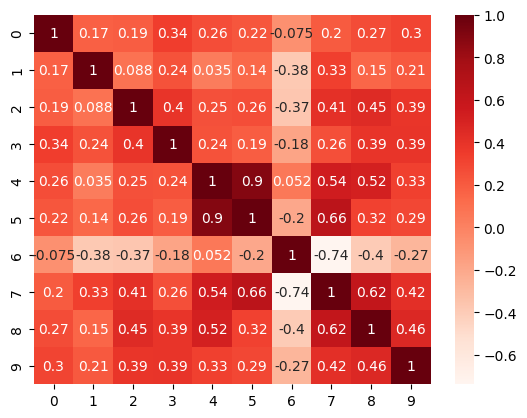

In [39]:
sns.heatmap(pd.DataFrame(X).corr(),annot=True,cmap='Reds')
plt.show()

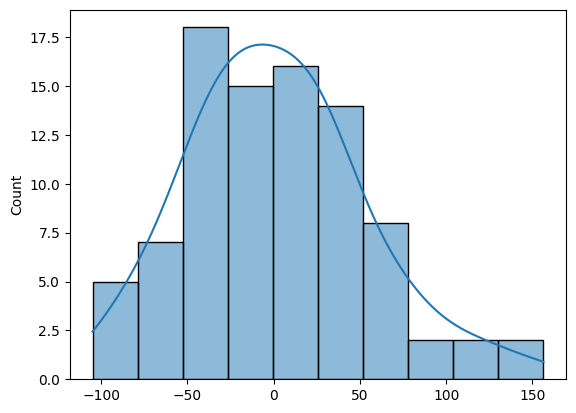

In [12]:
import matplotlib.pyplot as plt

residual=y_test-y_pred
sns.histplot(x=residual,kde=True)
plt.show()

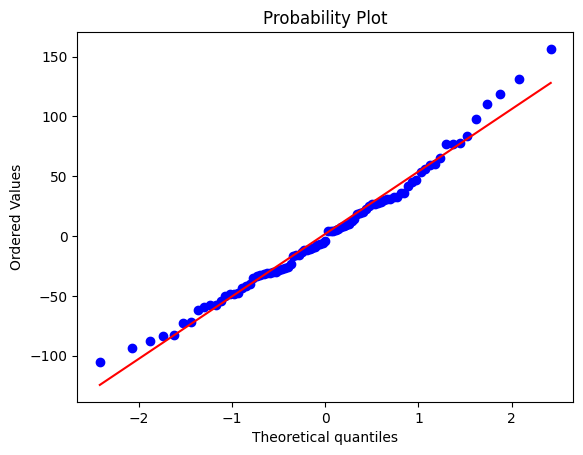

In [18]:
from scipy import stats
stats.probplot(residual,dist='norm',plot=plt)
plt.show()

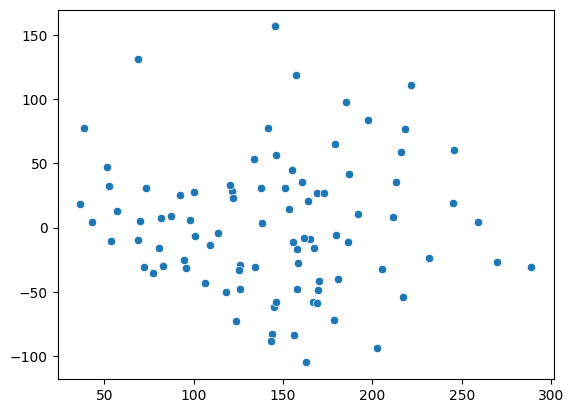

In [13]:
# Homoscedasticity

sns.scatterplot(x=y_pred,y=residual)
plt.show()

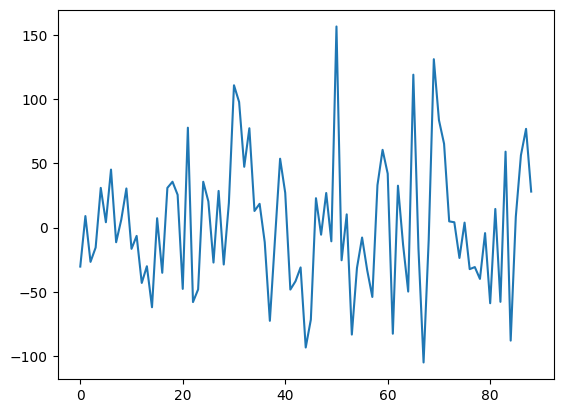

In [20]:
sns.lineplot(residual)
plt.show()